## Import Needed Package

In [1]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data_path = './dataset/dataset/Training'

filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
     f_path = os.path.join(train_data_path , fold)
     if os.path.isdir(f_path):
        filelists = os.listdir(f_path)
            
        for file in filelists:
            filepaths.append(os.path.join(f_path , file))
            labels.append(fold)
                
#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
train_df = pd.concat([Fseries , Lseries] , axis = 1)

In [3]:
train_df

,filepaths,labels
0,./dataset/dataset/Training\glioma\Tr-glTr_0000...,glioma
1,./dataset/dataset/Training\glioma\Tr-glTr_0001...,glioma
2,./dataset/dataset/Training\glioma\Tr-glTr_0002...,glioma
3,./dataset/dataset/Training\glioma\Tr-glTr_0003...,glioma
4,./dataset/dataset/Training\glioma\Tr-glTr_0004...,glioma
...,...,...
5707,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5708,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5709,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary
5710,./dataset/dataset/Training\pituitary\Tr-pi_145...,pituitary


In [4]:
test_data_path = './dataset/dataset/Testing'

filepaths = []
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
     f_path = os.path.join(test_data_path , fold)
     if os.path.isdir(f_path):
        filelists = os.listdir(f_path)
            
        for file in filelists:
            filepaths.append(os.path.join(f_path , file))
            labels.append(fold)
                
#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [5]:
test_df

,filepaths,labels
0,./dataset/dataset/Testing\glioma\Te-glTr_0000.jpg,glioma
1,./dataset/dataset/Testing\glioma\Te-glTr_0001.jpg,glioma
2,./dataset/dataset/Testing\glioma\Te-glTr_0002.jpg,glioma
3,./dataset/dataset/Testing\glioma\Te-glTr_0003.jpg,glioma
4,./dataset/dataset/Testing\glioma\Te-glTr_0004.jpg,glioma
...,...,...
1306,./dataset/dataset/Testing\pituitary\Te-pi_0295...,pituitary
1307,./dataset/dataset/Testing\pituitary\Te-pi_0296...,pituitary
1308,./dataset/dataset/Testing\pituitary\Te-pi_0297...,pituitary
1309,./dataset/dataset/Testing\pituitary\Te-pi_0298...,pituitary


#### Data Splitting

In [6]:
valid, test = train_test_split(test_df, train_size = 0.5, shuffle = True, random_state= 42)

In [7]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


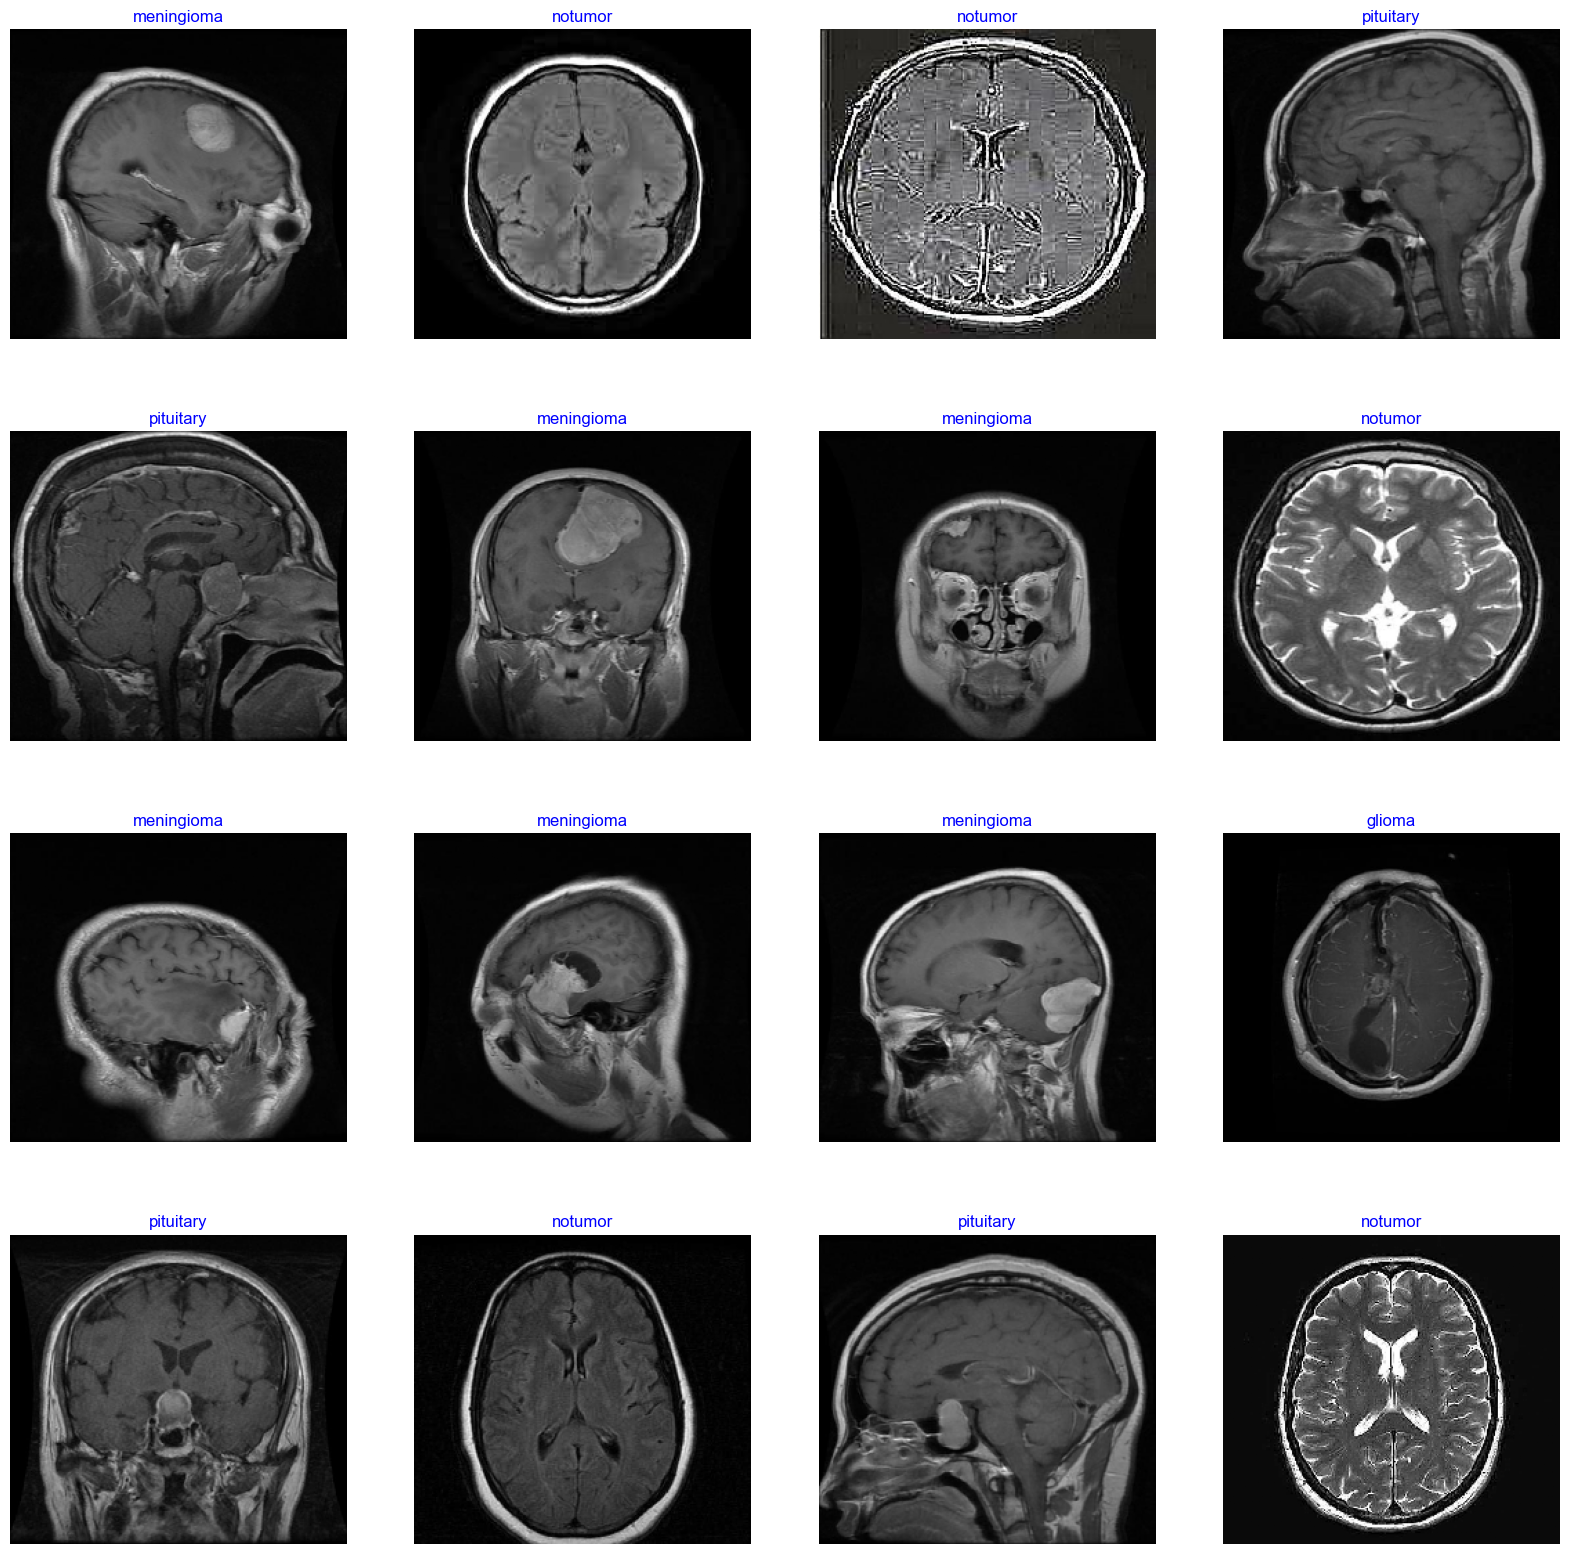

In [8]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_gen)

plt.figure(figsize = (20, 20))

for i in range(16):
    plt.subplot(4 ,4 , i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name , color = 'blue', fontsize = 12)
    plt.axis('off')
plt.show()

In [9]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

## Training Model

In [10]:
Epochs = 10

history = model.fit(
    train_gen,
    epochs=Epochs,
    verbose=1,
    validation_data=valid_gen,
    shuffle=True
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 818s 2s/step - accuracy: 0.4596 - loss: 7.6567 - val_accuracy: 0.3618 - val_loss: 5.4515
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 688s 2s/step - accuracy: 0.3305 - loss: 4.4520 - val_accuracy: 0.3527 - val_loss: 3.6268
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.3083 - loss: 3.0477 - val_accuracy: 0.3328 - val_loss: 2.5351
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.4177 - loss: 2.1757 - val_accuracy: 0.5511 - val_loss: 1.8142
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.5280 - loss: 1.6879 - val_accuracy: 0.6702 - val_loss: 1.3967
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.7258 - loss: 1.3355 - val_accuracy: 0.9221 - val_loss: 1.0576
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 712s 2s/step - accuracy: 0.8302 - loss: 1.0849 - val_accuracy: 0.9435 - val_loss: 0.8352
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 724s 2s/step - accuracy: 0.8486 - loss: 0.9118 - val_accu

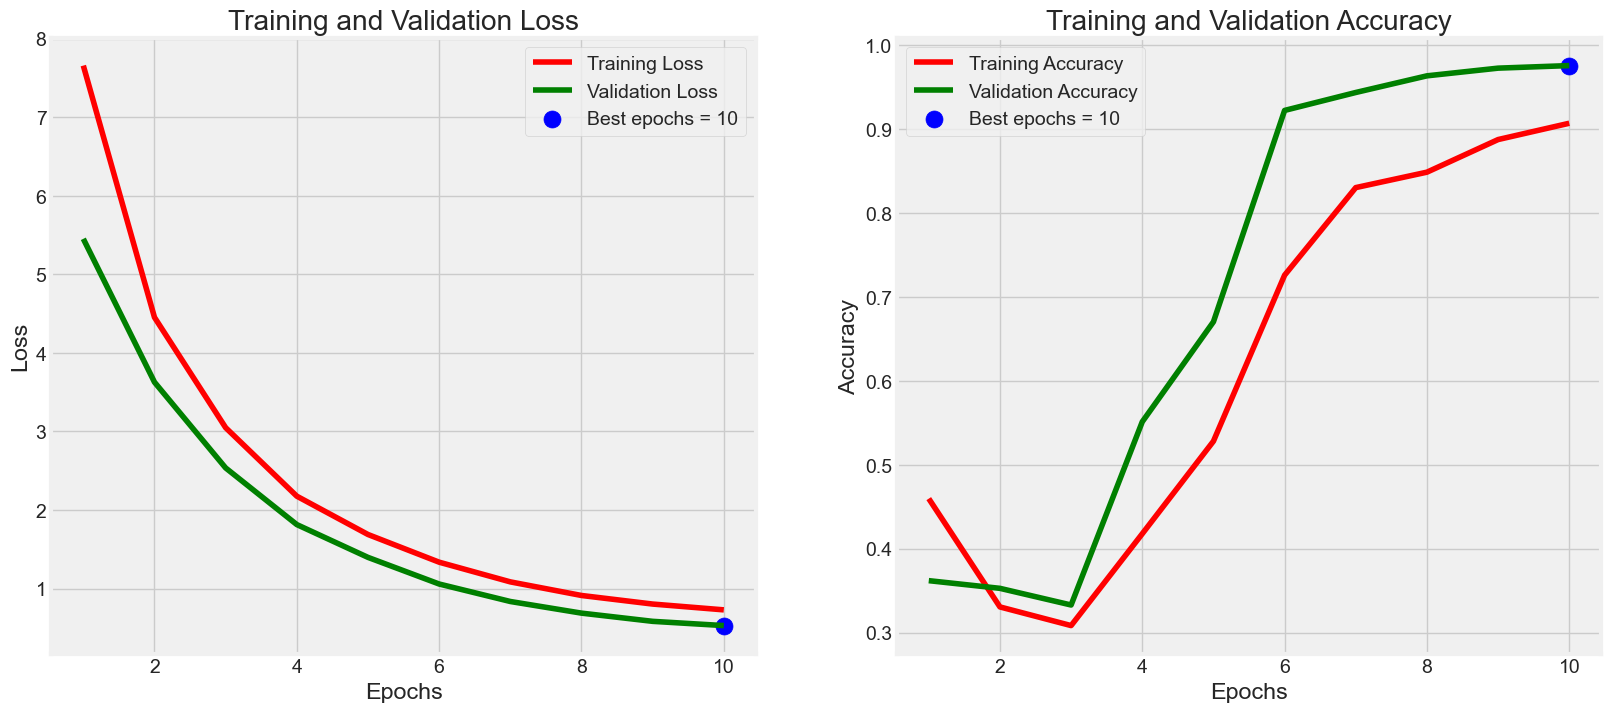

In [11]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [12]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step - accuracy: 0.9844 - loss: 0.5170
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - accuracy: 0.9766 - loss: 0.5283
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step - accuracy: 0.9688 - loss: 0.5497
Train Loss:  0.5169988870620728
Train Accuracy:  0.984375
--------------------
Validation Loss:  0.5283140540122986
Validation Accuracy:  0.9765625
--------------------
Test Loss:  0.549741268157959
Test Accuracy:  0.96875


In [13]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 433ms/step


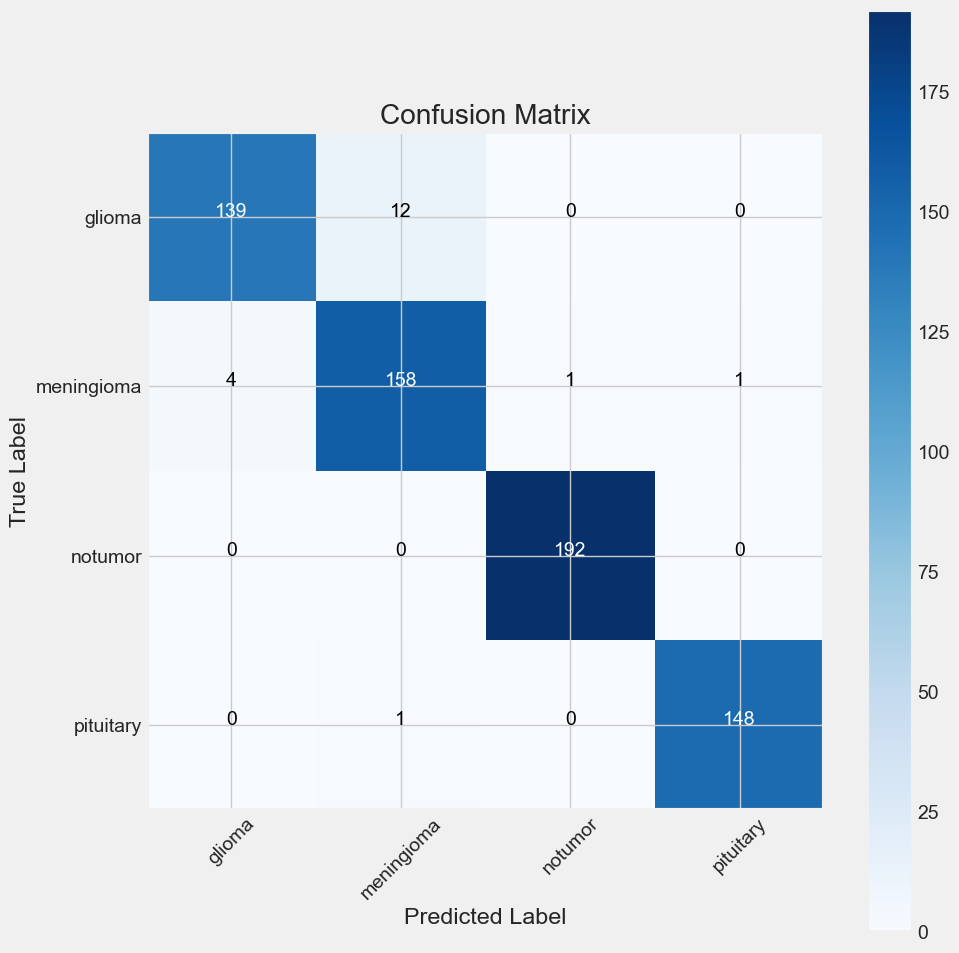

In [14]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [15]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.97      0.92      0.95       151
  meningioma       0.92      0.96      0.94       164
     notumor       0.99      1.00      1.00       192
   pituitary       0.99      0.99      0.99       149

    accuracy                           0.97       656
   macro avg       0.97      0.97      0.97       656
weighted avg       0.97      0.97      0.97       656



In [16]:
model.save("model.h5")

In [17]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [18]:
model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [23]:
gambar = tf.keras.preprocessing.image.load_img('./dataset/dataset/Testing/glioma/Te-glTr_0000.jpg', target_size=img_size)

In [25]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [26]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [27]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [28]:
print(predicted_class)

[0]


In [29]:
names = [classes[i] for i in predicted_class]
print(names)

['glioma']
